# Notebook 08 – Data Coverage Audit

Simple question: **does the survey have enough respondents in each Persona / Mood / Device context to support a full UI profile?**

| Label | Meaning |
|-------|--------|
| **Sufficient** | ≥ 10 respondents — safe for evidence-based UI |
| **Borderline** | 5–9 respondents — usable with caution |
| **Insufficient** | < 5 respondents — do not claim a full custom UI |

This explains why some JSON base profiles are thin: the data is complete on UI answers, but many **exact context combinations** are rare.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _bootstrap_project() -> Path:
    search_from = Path.cwd().resolve()
    candidates = [search_from, *search_from.parents]
    nested_root = search_from / "EvidenceBasedAdaptiveUI"
    if (nested_root / "src" / "config.py").exists():
        candidates.insert(0, nested_root)
    for candidate in candidates:
        if (candidate / "src" / "config.py").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise FileNotFoundError("Could not find project root containing src/config.py.")


PROJECT_ROOT = _bootstrap_project()

from src.evidence_engine.coverage import run_coverage_audit
from src.utils.notebook import setup_notebook

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
plt.rcParams["figure.dpi"] = 200

PATHS, REPORTS = setup_notebook("CoverageAudit")
print(f"Reports: {REPORTS}")

Reports: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit


## Load clean dataset

In [2]:
df = pd.read_csv(PATHS.data_processed / "clean_dataset.csv")
print(f"Respondents: {len(df)}")
display(df[["primary_persona", "current_mood", "primary_device"]].head(3))

Respondents: 200


,primary_persona,current_mood,primary_device
0,The Impulsive Buyer (I make quick decisions ba...,Neutral,Smartphone
1,The Loyal Customer (I stick with brands and st...,Happy,Smartphone
2,"The Minimalist (I want simple, efficient shopp...",Happy,Smartphone


## Run coverage audit

In [3]:
result = run_coverage_audit(df, REPORTS)

print(result.markdown)

# Data Coverage Audit

## Bottom line

The survey has **complete UI answers** (no missing UI fields), but **full Persona + Mood + Device combinations are often too small** to support a complete evidence-based UI profile.

- Respondents: **200**
- UI elements measured: **41**
- Full Persona×Mood×Device cells: **59** (Sufficient=3, Borderline=10, Insufficient=46)
- Median respondents per full cell: **2**

## How to read the labels

- **Sufficient** — at least 10 respondents in that context. Safe to mine association rules and claim a UI preference.
- **Borderline** — 5–9 respondents. Usable with caution; expect thin / incomplete profiles.
- **Insufficient** — fewer than 5 respondents. Do **not** claim a full evidence-backed UI for this exact context.

## What this means for the website

- Coarse contexts (e.g. Persona only) look healthy: 6/6 Sufficient.
- Fine contexts (Persona×Mood×Device) are mostly sparse — this is why many JSON base profiles have only a few UI keys.
- Recommended webs

## Grain-by-grain summary

Read this table first. It tells you which context levels are safe to use.

In [4]:
display(result.grain_summary)

,Grain,Cells,Sufficient,Borderline,Insufficient,Median_n,Mean_n,Max_n,Verdict
0,Persona,6,6,0,0,29.0,33.3,52,Good — most cells have enough respondents
1,Mood,8,6,1,1,17.5,25.0,77,Good — most cells have enough respondents
2,Device,2,2,0,0,100.0,100.0,163,Good — most cells have enough respondents
3,Persona×Mood,39,5,10,24,4.0,5.1,24,Weak — most cells are too small for full UI pr...
4,Persona×Device,12,8,0,4,16.0,16.7,38,"Partial — usable for some contexts, sparse for..."
5,Mood×Device,16,6,3,7,5.5,12.5,62,"Partial — usable for some contexts, sparse for..."
6,Persona×Mood×Device,59,3,10,46,2.0,3.4,19,Weak — most cells are too small for full UI pr...


## Full Persona × Mood × Device cells

These are the exact contexts the website would ideally personalize. Green = enough data; red = too few people.

In [5]:
display(
    result.full_cells[
        ["primary_persona", "current_mood", "primary_device", "n", "Coverage"]
    ]
)

,primary_persona,current_mood,primary_device,n,Coverage
83,Researcher,Neutral,Smartphone,19,Sufficient
84,Minimalist,Neutral,Smartphone,13,Sufficient
85,Researcher,Relaxed,Smartphone,10,Sufficient
86,Impulsive Buyer,Neutral,Smartphone,9,Borderline
87,Minimalist,Relaxed,Smartphone,8,Borderline
88,Deal Hunter,Neutral,Smartphone,8,Borderline
89,Browser,Neutral,Smartphone,7,Borderline
90,Browser,Stressed,Smartphone,7,Borderline
91,Loyal Customer,Neutral,Smartphone,6,Borderline
92,Impulsive Buyer,Relaxed,Smartphone,6,Borderline


## UI preference signal

If almost everyone chose the same option for a UI element, there is little room to adapt it.

In [6]:
display(result.ui_summary.head(20))

,UI_Element,Unique_Values,Missing_Pct,Top_Share,Top_Value,Signal
0,mobile_whitespace,3,0.0,0.850,Balanced,Low signal (one value dominates)
1,mobile_image_text_ratio,3,0.0,0.830,Balanced,Low signal (one value dominates)
2,desktop_persistent_filters,2,0.0,0.750,Yes,Low signal (one value dominates)
3,whitespace_pref,3,0.0,0.735,Balanced,Low signal (one value dominates)
4,desktop_info_density,3,0.0,0.725,Moderate,Low signal (one value dominates)
5,mobile_info_density,3,0.0,0.685,Moderate,Moderate signal
6,mobile_sticky_header,2,0.0,0.645,Yes,Moderate signal
7,mobile_price_display,3,0.0,0.625,Strike-through Original,Moderate signal
8,accent_color_pref,7,0.0,0.605,Blue,Moderate signal
9,mobile_filter_location,3,0.0,0.580,Drawer Overlay,Moderate signal


## Figures

coverage_by_grain.png


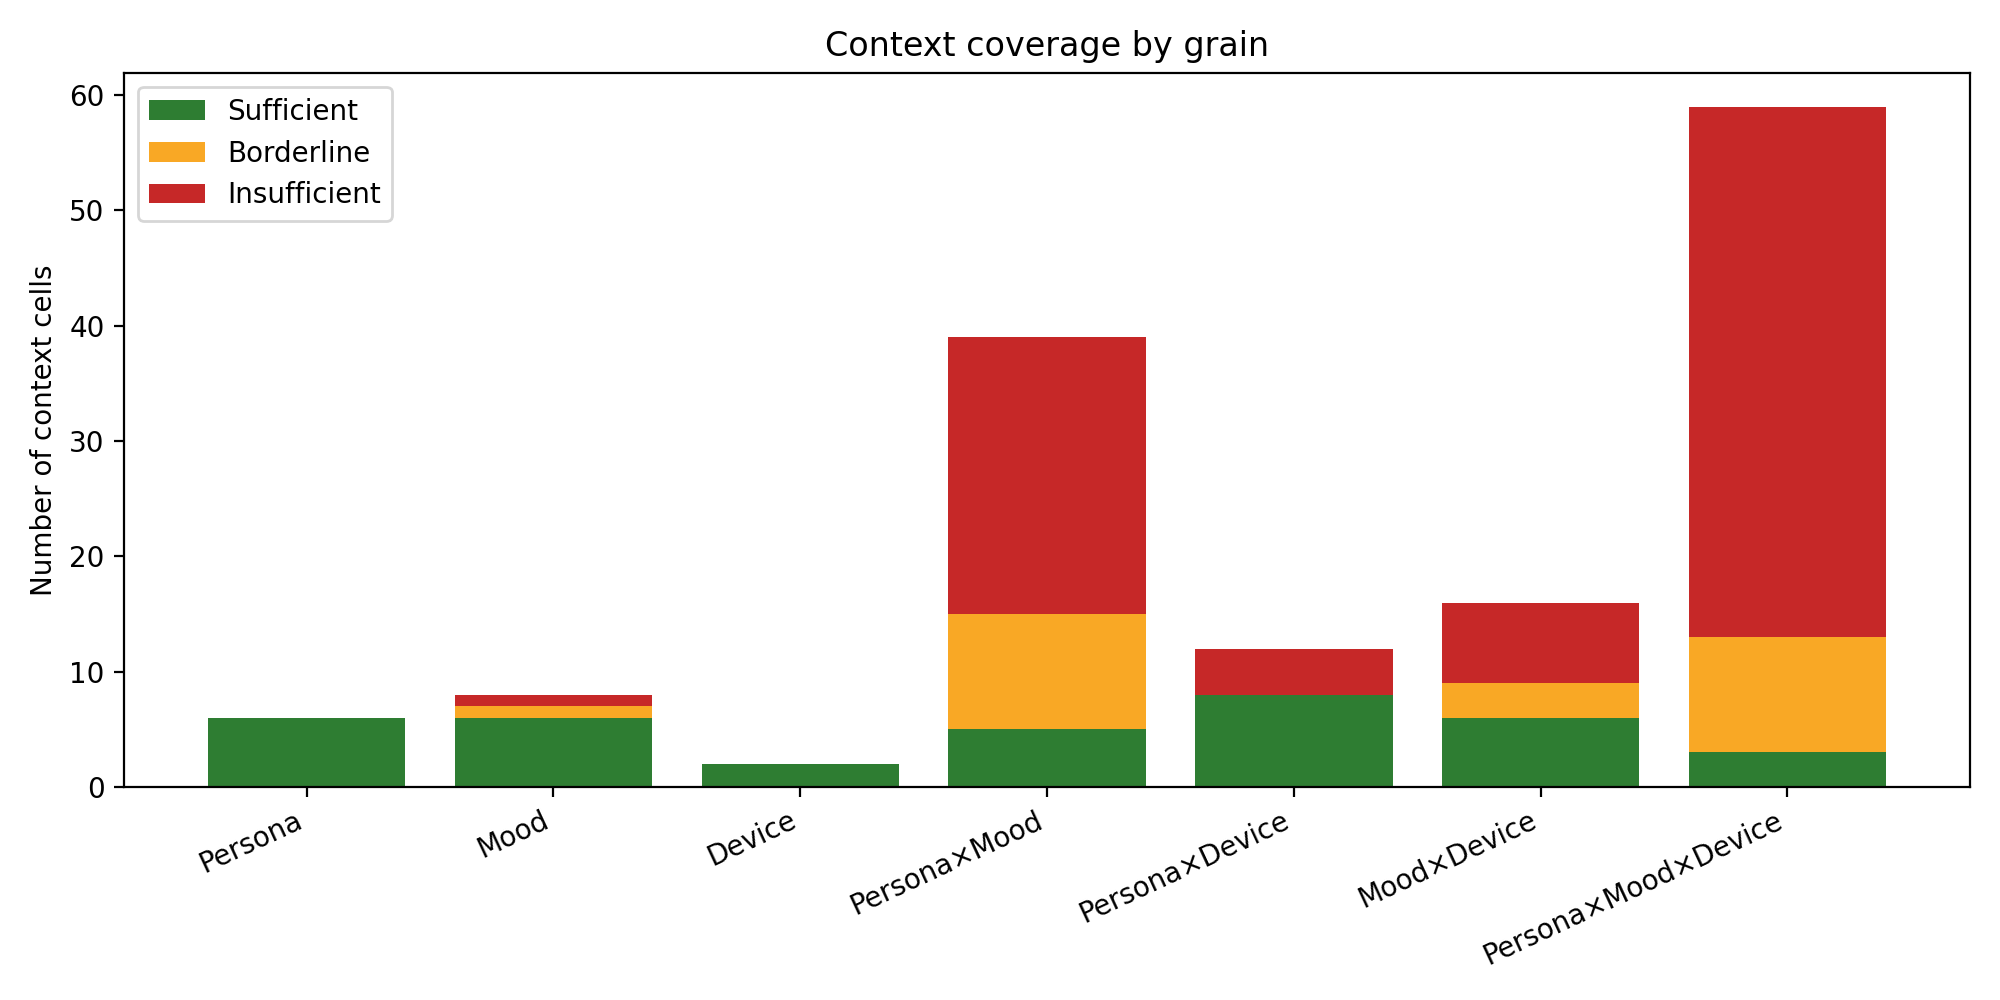

full_context_cell_sizes.png


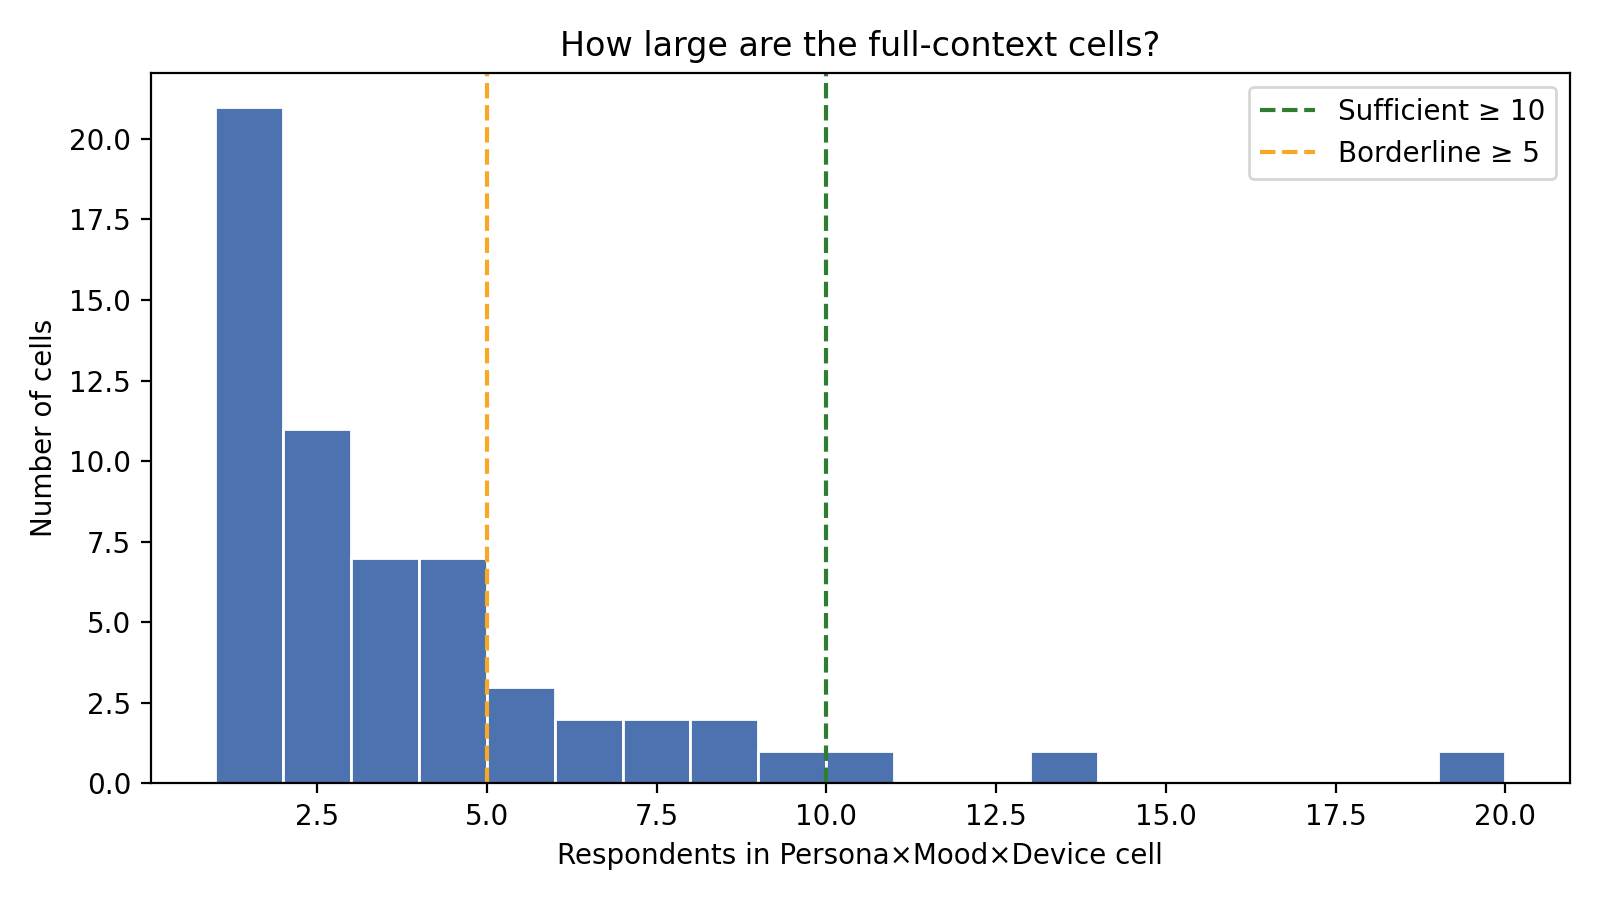

In [7]:
from IPython.display import Image, display as ipy_display

for name in ["coverage_by_grain.png", "full_context_cell_sizes.png"]:
    path = REPORTS / "figures" / name
    if path.exists():
        print(name)
        ipy_display(Image(filename=str(path)))

## Exports

In [8]:
print("Export locations:")
for name, path in result.export_paths.items():
    print(f"- {name}: {path}")

Export locations:
- context_coverage_cells_xlsx: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit/context_coverage_cells.xlsx
- ui_preference_signal_csv: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit/ui_preference_signal.csv
- coverage_audit_md: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit/coverage_audit.md
- coverage_by_grain_png: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit/figures/coverage_by_grain.png
- full_cell_sizes_png: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/CoverageAudit/figures/full_context_cell_sizes.png


# Notebook 10 – Runtime Simulation

Simulate the **adaptive engine** before integrating it into the React website.

This notebook does **not** create new evidence or repository data. It composes the
layered pipeline from Notebook 09 in the same order the website will use:

1. Load device defaults (`global` + `mobile` or `desktop`)
2. Apply persona overrides
3. Apply mood overrides
4. Apply Big Five trait nudges (ordinal styling shifts)
5. Export the final UI configuration JSON

If this notebook runs correctly, the adaptive engine is ready for React integration.
Saved outputs also serve as thesis evaluation artifacts.

## Inputs
- `data/outputs/adaptive_repository/` (Notebook 09)

## Outputs
- `data/outputs/runtime_simulation/` — final UI configurations + full traces
- `reports/RuntimeSimulation/simulation_summary.xlsx`

In [ ]:
import json
import logging
import sys
from pathlib import Path

import pandas as pd


def _bootstrap_project() -> Path:
    search_from = Path.cwd().resolve()
    candidates = [search_from, *search_from.parents]
    nested_root = search_from / "EvidenceBasedAdaptiveUI"
    if (nested_root / "src" / "config.py").exists():
        candidates.insert(0, nested_root)
    for candidate in candidates:
        if (candidate / "src" / "config.py").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise FileNotFoundError("Could not find project root containing src/config.py.")


PROJECT_ROOT = _bootstrap_project()

from src.runtime_simulation.engine import (
    RuntimeContext,
    list_available_contexts,
    run_runtime_simulation,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

REPOSITORY_DIR = PROJECT_ROOT / "data" / "outputs" / "adaptive_repository"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "runtime_simulation"
REPORTS_DIR = PROJECT_ROOT / "reports" / "RuntimeSimulation"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository: {REPOSITORY_DIR}")
print(f"Simulation output: {OUTPUT_DIR}")
print(f"Reports: {REPORTS_DIR}")

Repository: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/adaptive_repository
Simulation output: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation
Reports: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/RuntimeSimulation


## Available context values

These come directly from the adaptive repository (Notebook 09). The example below uses
`Explorer` as a demo alias for the survey persona **Browser**.

In [ ]:
available = list_available_contexts(REPOSITORY_DIR)
print(json.dumps(available, indent=2))

{
  "devices": [
    "Smartphone",
    "Desktop"
  ],
  "personas": [
    "Browser",
    "Deal Hunter",
    "Impulsive Buyer",
    "Loyal Customer",
    "Minimalist",
    "Researcher"
  ],
  "moods": [
    "Bored",
    "Excited",
    "Frustrated",
    "Happy",
    "Neutral",
    "Relaxed",
    "Sad",
    "Stressed"
  ],
  "traits": {
    "Extraversion": [
      "High",
      "Low"
    ],
    "Agreeableness": [
      "High",
      "Low"
    ],
    "Conscientiousness": [
      "High",
      "Low"
    ],
    "Neuroticism": [
      "High"
    ],
    "Openness": [
      "High",
      "Low"
    ]
  },
  "persona_aliases": {
    "Explorer": "Browser"
  }
}


## Example scenario

| Input | Value |
|-------|-------|
| Device | Smartphone |
| Persona | Explorer *(→ Browser)* |
| Mood | Happy |
| Openness | High |

**Pipeline:**

```
Smartphone → mobile_defaults.json
  → Explorer persona overrides
  → Happy mood overrides
  → High Openness nudges
  → Final UI Configuration (JSON)
```

In [ ]:
example_context = RuntimeContext(
    device="Smartphone",
    persona="Explorer",
    mood="Happy",
    personality={"Openness": "High"},
)

example_output_path = OUTPUT_DIR / "smartphone_explorer_happy_high_openness.json"
example_result = run_runtime_simulation(
    example_context,
    REPOSITORY_DIR,
    output_path=example_output_path,
)

print("Resolved context:", json.dumps(example_result.context, indent=2))
print("Warnings:", example_result.warnings or "none")
print("Metadata:", json.dumps(example_result.metadata, indent=2))

INFO: Saved runtime simulation output to /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation/smartphone_explorer_happy_high_openness.json


Resolved context: {
  "device": "Smartphone",
  "device_defaults": "mobile_defaults",
  "persona": "Browser",
  "mood": "Happy",
  "personality": {
    "Openness": "High"
  }
}
Warnings: none
Metadata: {
  "pipeline": [
    "global_defaults",
    "mobile_defaults",
    "persona_overrides",
    "mood_overrides",
    "trait_nudges"
  ],
  "n_ui_elements": 34,
  "n_persona_overrides": 7,
  "n_mood_overrides": 6,
  "n_trait_nudges": 2
}


## Layer-by-layer trace

In [ ]:
for step in example_result.trace:
    layer = step.get("layer", step.get("source", "?"))
    print(f"\n--- Step {step.get('step')}: {layer} ---")
    if layer == "defaults":
        print(f"Loaded {step['n_elements']} global default elements from {step['source']}")
    elif layer == "device_defaults":
        print(f"Loaded {step['n_elements']} {step['device']} elements from {step['source']}")
    elif layer in {"persona_overrides", "mood_overrides"}:
        print(f"Applied {step['n_applied']} overrides")
        display(pd.DataFrame(step["applied"]))
    elif layer == "trait_nudges":
        print(f"Applied {step['n_applied']} ordinal nudges")
        display(pd.DataFrame(step["applied"]))


--- Step 1: defaults ---
Loaded 14 global default elements from global_defaults.json

--- Step 2: device_defaults ---
Loaded 14 Smartphone elements from mobile_defaults.json

--- Step 3: persona_overrides ---
Applied 7 overrides


,ui_element,previous,value,confidence
0,font_style_pref,2. Classic Serif (Traditional fonts with decor...,"1. Modern Sans-serif (Clean, contemporary font...",0.300000
1,color_theme_pref,"Minimalist Black & White (Clean, high contrast...","Vibrant Bold (Bright, energetic colors - excit...",0.300000
2,urgency_pref,Both (Show both stock and time based urgency),None (I find these annoying and manipulative),0.333333
3,form_field_style,Rounded Border Fields (Outlined field with rou...,Outlined (Border around the field),0.300000
4,desktop_navigation,None,Mega Menu (Dropdown with images and subcategor...,0.333333
5,desktop_review_display,None,All Paginated (Show all reviews with pagination),0.566667
6,mobile_sticky_header,Yes (Header stays at top while scrolling),No (Header scrolls away with content),0.533333



--- Step 4: mood_overrides ---
Applied 6 overrides


,ui_element,previous,value,confidence
0,checkout_style,One Page (All checkout steps on a single scrol...,Progress Bar (Multi step with visual progress ...,0.588235
1,desktop_grid_pref,None,"2 Columns (Large product images, fewer items p...",0.352941
2,desktop_search_visibility,None,Collapsible (Search bar that expands when clic...,0.764706
3,desktop_price_display,None,With Comparison (Shows similar products' prices),0.411765
4,desktop_filter_location,None,Top Bar (Filters displayed across the top),0.470588
5,mobile_category_display,Dropdown Menu (Text-based dropdown list),Visual Grid (Category tiles with images),0.352941



--- Step 5: trait_nudges ---
Applied 2 ordinal nudges


,trait,level,property,ui_element,delta,previous,value,confidence
0,Openness,High,visual_richness,mobile_image_text_ratio,1,"Balanced (50% images, 50% text - equal emphasis)","Image-focused (80% images, 20% text - highly v...",0.405088
1,Openness,High,visual_richness,hero_banner_size,1,Medium Split (Takes up half the screen),Large Full screen (Takes up entire first screen),0.405088


## Final UI configuration

In [ ]:
final_df = pd.DataFrame(
    [
        {"ui_element": key, "value": value}
        for key, value in example_result.final_ui_configuration.items()
    ]
)
display(final_df)
print(f"\nSaved to: {example_output_path}")

,ui_element,value
0,accent_color_pref,"Blue (Trustworthy, professional, calm)"
1,background_pref,"Cream/Off-white (Warm, comfortable, paper-like)"
2,button_style_pref,"Rounded Corners (Soft, modern rounded edges)"
3,checkout_style,Progress Bar (Multi step with visual progress ...
4,color_theme_pref,"Vibrant Bold (Bright, energetic colors - excit..."
5,desktop_filter_location,Top Bar (Filters displayed across the top)
6,desktop_grid_pref,"2 Columns (Large product images, fewer items p..."
7,desktop_navigation,Mega Menu (Dropdown with images and subcategor...
8,desktop_price_display,With Comparison (Shows similar products' prices)
9,desktop_review_display,All Paginated (Show all reviews with pagination)



Saved to: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation/smartphone_explorer_happy_high_openness.json


## Additional scenarios

Run a small batch to demonstrate that different contexts produce different final configurations.

In [ ]:
batch_scenarios = [
    RuntimeContext(
        device="Desktop",
        persona="Researcher",
        mood="Stressed",
        personality={"Neuroticism": "High", "Conscientiousness": "High"},
    ),
    RuntimeContext(
        device="Smartphone",
        persona="Minimalist",
        mood="Relaxed",
        personality={"Openness": "Low"},
    ),
    RuntimeContext(
        device="Desktop",
        persona="Deal Hunter",
        mood="Excited",
        personality={"Extraversion": "High"},
    ),
]

summary_rows = []
for index, context in enumerate(batch_scenarios, start=1):
    slug = f"scenario_{index:02d}"
    output_path = OUTPUT_DIR / f"{slug}.json"
    result = run_runtime_simulation(context, REPOSITORY_DIR, output_path=output_path)
    summary_rows.append(
        {
            "scenario": slug,
            "device": result.context["device"],
            "persona": result.context["persona"],
            "mood": result.context["mood"],
            "personality": json.dumps(result.context["personality"]),
            "n_ui_elements": result.metadata["n_ui_elements"],
            "n_persona_overrides": result.metadata["n_persona_overrides"],
            "n_mood_overrides": result.metadata["n_mood_overrides"],
            "n_trait_nudges": result.metadata["n_trait_nudges"],
            "output_file": output_path.name,
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_xlsx = REPORTS_DIR / "simulation_summary.xlsx"
with pd.ExcelWriter(summary_xlsx, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="scenarios", index=False)
    pd.DataFrame(
        [
            {"ui_element": key, "value": value}
            for key, value in example_result.final_ui_configuration.items()
        ]
    ).to_excel(writer, sheet_name="example_final_ui", index=False)

print(f"Summary saved to: {summary_xlsx}")

INFO: Saved runtime simulation output to /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation/scenario_01.json
INFO: Saved runtime simulation output to /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation/scenario_02.json
INFO: Saved runtime simulation output to /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/runtime_simulation/scenario_03.json


,scenario,device,persona,mood,personality,n_ui_elements,n_persona_overrides,n_mood_overrides,n_trait_nudges,output_file
0,scenario_01,Desktop,Researcher,Stressed,"{""Neuroticism"": ""High"", ""Conscientiousness"": ""...",29,6,6,5,scenario_01.json
1,scenario_02,Smartphone,Minimalist,Relaxed,"{""Openness"": ""Low""}",32,2,4,3,scenario_02.json
2,scenario_03,Desktop,Deal Hunter,Excited,"{""Extraversion"": ""High""}",28,3,4,2,scenario_03.json


Summary saved to: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/RuntimeSimulation/simulation_summary.xlsx


## Done

The runtime simulation confirms the layered adaptation pipeline behaves as intended.
Use the saved JSON files as evaluation artifacts and wire the same logic into React.